<h1 align="left">Captions Dataset</h1>

<p align="left"><i>PASTIS24 Dataset</i></p>

<p align="left">
  ITESM
  
  <a href="https://www.linkedin.com/in/juanrtato/">Juan Ricardo Albarracin B.</a>
  <br>
  <a href="">Luis Ángel Oporto Añacato.</a>
  <br>
  <a href="">David Alexis García Espinosa.</a>
  <br>
  <b>Last updated:</b> <i>07/06/2025</i>
  <br><br>
  <a target="_blank">
    <img src="https://github.com/QData/TextAttack/workflows/Github%20PyTest/badge.svg" alt="Testing">
  </a>
  <a href="https://img.shields.io/badge/version-0.1.0-blue.svg?cacheSeconds=2592000">
    <img src="https://img.shields.io/badge/version-0.1.0-blue.svg?cacheSeconds=2592000" alt="Version" height="18">
  </a>
</p><br>

In [15]:
PATH_TO_PASTIS = '../datalake/PASTIS24'
PATH_TO_CODE = '../scripts/pastis24'
PATH_TO_FOLDS = '../datalake/PASTIS24/fold-paths'
PATH_TO_PICKLES = '../datalake/PASTIS24/pickle24X24'
CONFIG_PATH = '../datalake/config_vtt.json'
METADATA_PATH = '../datalake/PASTIS24/metadata.geojson'

In [16]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'scripts')))
#sys.path.append(PATH_TO_CODE)

In [17]:
import ast
import json
import re
import random
from datetime import datetime, timedelta
from itertools import islice
import plotly.express as px
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import torch
import pastis24
from pastis24 import get_dataloaders

from utils import plot_sample_rgb, plot_seg_mask, plot_mean_band_profile, calculate_ndvi_by_crop

In [18]:
with open(METADATA_PATH, 'r') as f:
    metadata_json = json.load(f)

In [19]:
with open(CONFIG_PATH, 'r') as f:
    config = json.load(f)

In [20]:
with open("../datalake/label_names_en.json", "r") as json_file:
    label_names_en = json.load(json_file)

In [21]:
with open("../datalake/colormap.txt", "r") as txt_file:
    colormap = txt_file.readlines()
colormap = [ast.literal_eval(line.strip().rstrip(',')) for line in colormap]

Set dates formatting to True. This  ensure that the dates in the dataset of captions are formatted correctly, if necessary:

In [22]:
config['DATASETS']['eval']['format_dates'] = True
config['DATASETS']['train']['format_dates'] = True
config['DATASETS']['train']['normalize'] = False
config['DATASETS']['eval']['normalize'] = False

In [23]:
dataloaders = get_dataloaders(config)

Loading PASTIS2SEQUENCE dataset...
PASTIS2SEQUENCE dataset loaded!


../datalake/PASTIS24/pickle24x24/30233_14.pickle
<re.Match object; span=(0, 15), match='30233_14.pickle'>
Sample shape: (60, 24, 24, 11)
Sample labels shape: (24, 24, 1)


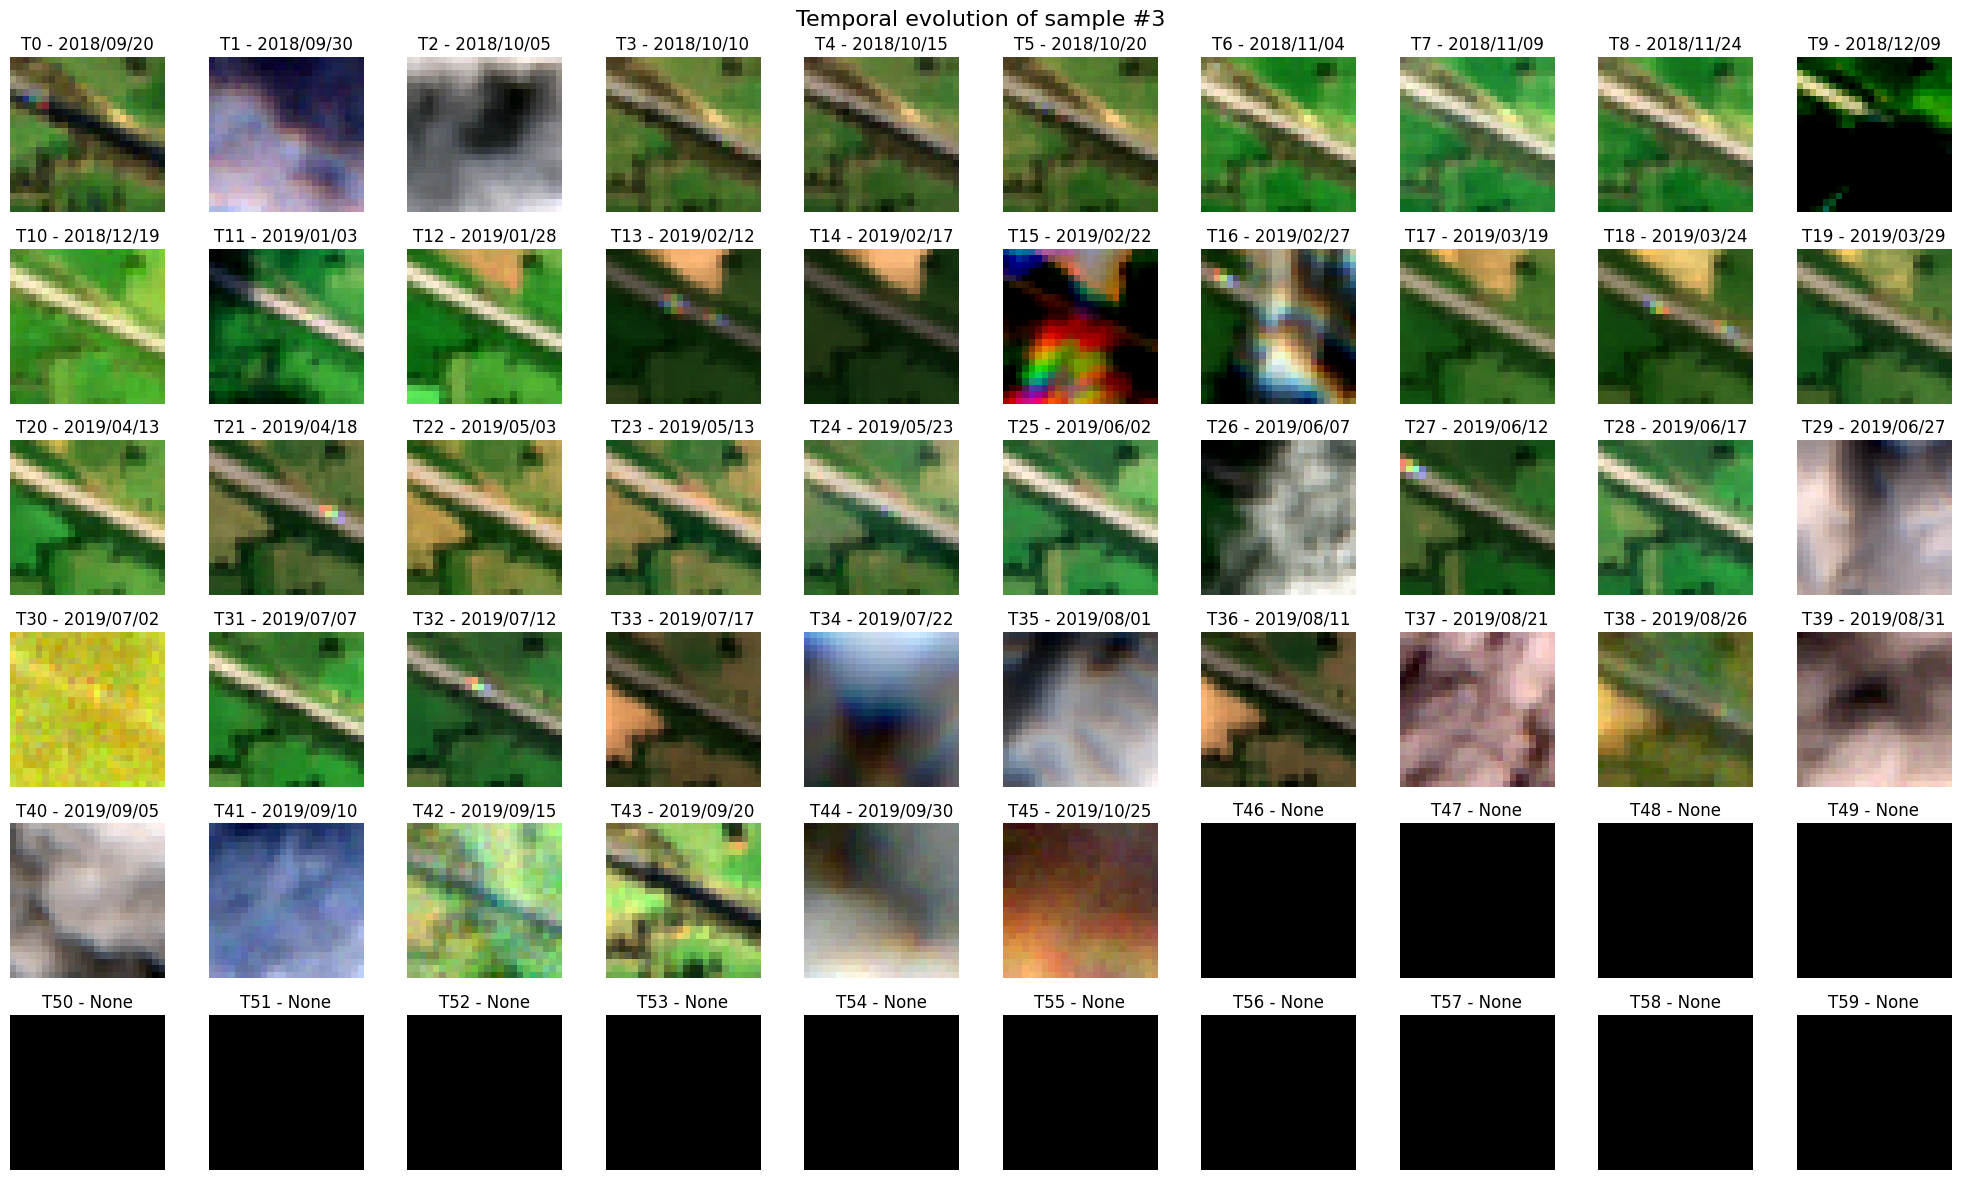

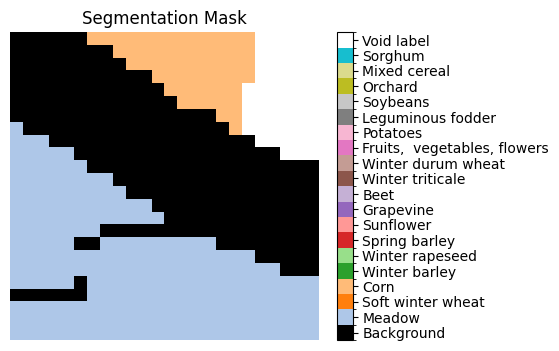

In [29]:
sample = next(iter(dataloaders['train']))
sample_dict, texts, img_path = sample
sample_idx = 3#random.randint(0, len(img_path)-1)
patch_id = 'UNKNOWN'
inputs = sample_dict['inputs']
labels = sample_dict['labels']
path_patch = img_path[sample_idx]
print(path_patch)
match = re.match(r"(\d+)_\d+\.pickle", os.path.basename(path_patch))
print(match)
if match:
    patch_id = match.group(1)
sample_labels = labels[sample_idx]
plot_sample_rgb(inputs, labels, patch_id, sample_idx=sample_idx)
plot_seg_mask(sample_labels[:, :, 0], colormap, label_names_en)

In [32]:
sample_idx

3

In [31]:
texts[sample_idx]

'The image shows a cultivated area of Meadow A crop of Meadow can be identified in the image with an approximate area of 22900 m2, Corn with a coverage of approximately 5600 m2 which corresponds to a relevant part of the cultivated area in this zone (about 57600 m2).\n\nWith respect to the crop periods, Meadow was likely cultivated beginning in mid-October and harvested about the end of January. In the same way, data indicates the crop Corn was planted near in the middle of October and harvested in the close of January.'

In [33]:
for text in texts:
    print(f"Text for patch {patch_id}:")
    if isinstance(text, str):
        print(text)
        print('\n\n')

Text for patch 30233:
The image shows the presence of Meadow with an approximate area of 25700 m2, Soft winter wheat spanning approximately 31500 m2 which represents a prominent portion of the region’s agricultural area (approximately 57600 m2).

On the topic of crop development stages, estimates point to a planting time by mid-October and a harvest period in the beginning of June for the crop Meadow. Additionally, Soft winter wheat was sown by mid-October and harvested by the midpoint of February.



Text for patch 30233:
The image highlights the crop of Meadow covering an area close to 30400 m2 which corresponds to a relevant part of the cultivated area in this zone (approx. 57600 m2).

Considering the crop seasonal phases, the observed agricultural timeline for Meadow suggests planting by the last days of September and harvesting about early July.



Text for patch 30233:
The crop appearing in the image is Soft winter wheat with an approximate area of 20700 m2, Soybeans with a cover